# L2R Atmospheric Correction with SMA Vicarious Calibration

This vignette demonstrates the full **L1C → L2R** processing chain for a cropped
ACI13 hyperspectral image of a coastal scene in the Gulf of St. Lawrence (Quebec,
July 2022).  It covers:

1. Loading a Level-1C (calibrated radiance) image
2. Fetching MERRA-2 atmospheric ancillary data
3. Applying a per-wavelength **Standard Major Axis (SMA)** vicarious calibration
   model fitted independently (e.g. in R)
4. Running the full atmospheric correction to produce water-leaving reflectance ρ_w
5. Inspecting the result as an RGB overview and spectral profiles

---

**Processing chain summary**

```
L(λ)  →  ρ_t(λ)  →  ρ_t_cal(λ)  →  ρ_s(λ)  →  ρ_w(λ)
                  ↑                ↑              ↑
           SMA calibration   AerLUT + GasLUT   G21 glint
```

All outputs are written as Zarr stores (parallel-write friendly) and optionally
exported as CF-1.0 NetCDF for use in QGIS or other GIS software.

In [1]:
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import xarray as xr

import aabim
from aabim import Image, SMAModel
from aabim.ancillary.get_ancillary import add_ancillary

# ── Paths ──────────────────────────────────────────────────────────────────
REPO_ROOT  = Path("../..")
DATA_DIR   = REPO_ROOT / "tests" / "data"
OUTPUT_DIR = DATA_DIR / "tmp"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

L1C_SRC  = DATA_DIR / "ACI13_bbox_l1c.nc"
L1C_COPY = OUTPUT_DIR / "ACI13_bbox_l1c_vignette.nc"
SMA_CSV  = DATA_DIR / "sma_calibration_model.csv"
L2R_ZARR = str(OUTPUT_DIR / "ACI13_bbox_l2r_sma.zarr")
L2R_NC   = str(OUTPUT_DIR / "ACI13_bbox_l2r_sma.nc")

print(f"Source L1C : {L1C_SRC}")
print(f"SMA model  : {SMA_CSV}")
print(f"L2R output : {L2R_ZARR}")

Source L1C : ../../tests/data/ACI13_bbox_l1c.nc
SMA model  : ../../tests/data/sma_calibration_model.csv
L2R output : ../../tests/data/tmp/ACI13_bbox_l2r_sma.zarr


/home/raphael/miniforge3/envs/aabim/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 — Load the L1C image

We work on a copy so the original fixture is never modified.

In [2]:
shutil.copy2(L1C_SRC, L1C_COPY)
img = Image.from_aabim_nc(str(L1C_COPY))

print(f"Image name : {img.image_name}")
print(f"Sensor     : {img.sensor}")
print(f"Dimensions : {img.n_rows} rows × {img.n_cols} cols")
print(f"Wavelengths: {len(img.wavelength)} bands  "
      f"[{img.wavelength[0]:.1f} – {img.wavelength[-1]:.1f} nm]")
print(f"Acquisition: {img.acq_time_z}")
print(f"CRS        : {img.CRS.to_epsg()}")

Image name : 220705_ACI-13A-WI-1x1x1_v01-L1CG
Sensor     : Sensor(name='unknown', wavelengths=array([361.51, 365.93, 370.36, 374.78, 379.21, 383.63, 388.05, 392.48,
       396.9 , 401.32, 405.74, 410.16, 414.58, 419.  , 423.42, 427.84,
       432.26, 436.68, 441.1 , 445.52, 449.93, 454.35, 458.77, 463.18,
       467.6 , 472.01, 476.43, 480.84, 485.25, 489.67, 494.08, 498.49,
       502.9 , 507.32, 511.73, 516.14, 520.55, 524.96, 529.37, 533.78,
       538.19, 542.6 , 547.  , 551.41, 555.82, 560.23, 564.63, 569.04,
       573.45, 577.85, 582.26, 586.66, 591.07, 595.47, 599.88, 604.28,
       608.69, 613.09, 617.49, 621.9 , 626.3 , 630.7 , 635.1 , 639.5 ,
       643.91, 648.31, 652.71, 657.11, 661.51, 665.91, 670.31, 674.71,
       679.11, 683.51, 687.9 , 692.3 , 696.7 , 701.1 , 705.5 , 709.89,
       714.29, 718.69, 723.09, 727.48, 731.88, 736.28, 740.67, 745.07,
       749.46, 753.86, 758.25, 762.65, 767.04, 771.44, 775.83, 780.23,
       784.62, 789.01, 793.41, 797.8 , 802.19, 806.59,

## 2 — Add MERRA-2 ancillary data

`add_ancillary` downloads the GMAO MERRA-2 Meteorological and Aerosol files for
the acquisition date/time from the NASA OB.DAAC (requires a NASA Earthdata account
in `~/.netrc`).  Downloaded files are cached in `anc_dir` so subsequent calls are
instant.

Variables added to the image dataset:

| Variable | Units | Source field |
|---|---|---|
| `aerosol_optical_depth_at_550_nm` | – | TOTEXTTAU |
| `surface_air_pressure` | hPa | PS |
| `atmosphere_mass_content_of_water_vapor` | g cm⁻² | TQV |
| `equivalent_thickness_at_stp_of_atmosphere_ozone_content` | cm-atm | TO3 |
| `wind_speed` / `wind_direction` | m s⁻¹ / ° | U10M, V10M |

In [3]:
add_ancillary(img, anc_dir=OUTPUT_DIR / "anc")

print("Ancillary variables added:")
anc_vars = [
    "aerosol_optical_depth_at_550_nm",
    "surface_air_pressure",
    "atmosphere_mass_content_of_water_vapor",
    "equivalent_thickness_at_stp_of_atmosphere_ozone_content",
    "wind_speed",
]
for v in anc_vars:
    val = float(img.in_ds[v].values)
    print(f"  {v:<55} {val:.4f}")

Ancillary variables added:
  aerosol_optical_depth_at_550_nm                         0.0585
  surface_air_pressure                                    1007.7570
  atmosphere_mass_content_of_water_vapor                  1.2593
  equivalent_thickness_at_stp_of_atmosphere_ozone_content 0.3858
  wind_speed                                              7.3132


/home/raphael/python_projects/aabim/aabim/ancillary/obpg/get_gmao.py:67: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  return xr.merge([met_anc, aer_anc])
/home/raphael/python_projects/aabim/aabim/ancillary/obpg/get_gmao.py:67: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  return xr.merge([met_anc, aer_anc])
/home/raphael/python_proje

## 3 — Load the SMA calibration model

The calibration CSV was fitted externally (e.g. in R using the `lmodel2` package)
and contains one row per wavelength with SMA slope `a`, intercept `b`, and their
95 % confidence intervals.  The `SMAModel.load()` constructor accepts any CSV with
a `wavelength` column plus at least `a` and `b` — extra columns (confidence
intervals, r²) are loaded as additional coefficient variables.

The calibration is applied as:
$$\rho_{t,\text{cal}}(\lambda) = a(\lambda)\,\rho_t(\lambda) + b(\lambda)$$

In [4]:
sma_model = SMAModel.load(str(SMA_CSV))
sma_model.summary()

print(f"\nCoefficient columns: {list(sma_model.coeffs.data_vars)}")
print(f"Spectral coverage  : {sma_model.wavelength[0]:.2f} – "
      f"{sma_model.wavelength[-1]:.2f} nm  ({len(sma_model.wavelength)} bands)")

Model      : sma
Wavelengths: 97 bands [375–798 nm]
<xarray.Dataset> Size: 5kB
Dimensions:     (wavelength: 97)
Coordinates:
  * wavelength  (wavelength) float64 776B 374.8 379.2 383.6 ... 793.4 797.8
Data variables:
    a           (wavelength) float64 776B 0.1597 0.2043 0.1915 ... 0.1008 0.1202
    b           (wavelength) float64 776B 0.05564 0.05082 ... 0.004792 0.00462
    a_low       (wavelength) float64 776B 0.1318 0.1704 ... 0.08483 0.1007
    a_high      (wavelength) float64 776B 0.1937 0.2449 0.2296 ... 0.1197 0.1435
    b_low       (wavelength) float64 776B 0.05363 0.04844 ... 0.004547 0.004321
    b_high      (wavelength) float64 776B 0.05729 0.0528 ... 0.004998 0.004871

Coefficient columns: ['a', 'b', 'a_low', 'a_high', 'b_low', 'b_high']
Spectral coverage  : 374.78 – 797.80 nm  (97 bands)


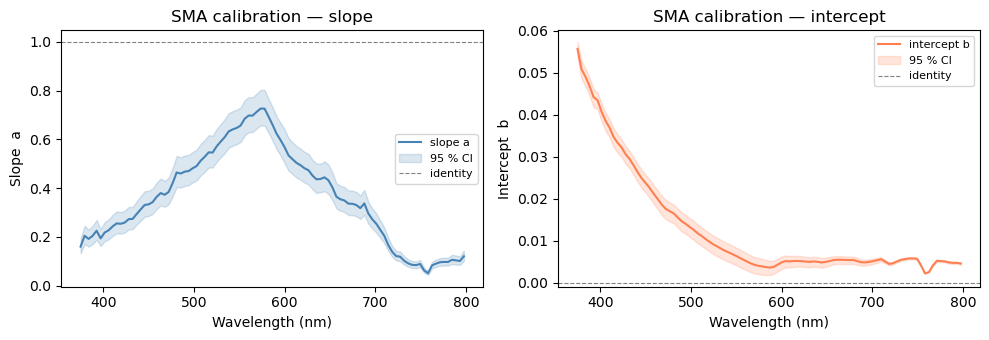

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
wl_cal = sma_model.wavelength

ax = axes[0]
ax.plot(wl_cal, sma_model.coeffs["a"].values, color="steelblue", lw=1.5, label="slope a")
ax.fill_between(wl_cal,
                sma_model.coeffs["a_low"].values,
                sma_model.coeffs["a_high"].values,
                alpha=0.2, color="steelblue", label="95 % CI")
ax.axhline(1, color="gray", lw=0.8, ls="--", label="identity")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Slope  a")
ax.set_title("SMA calibration — slope")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(wl_cal, sma_model.coeffs["b"].values, color="coral", lw=1.5, label="intercept b")
ax.fill_between(wl_cal,
                sma_model.coeffs["b_low"].values,
                sma_model.coeffs["b_high"].values,
                alpha=0.2, color="coral", label="95 % CI")
ax.axhline(0, color="gray", lw=0.8, ls="--", label="identity")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Intercept  b")
ax.set_title("SMA calibration — intercept")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4 — Clip to calibration model spectral range

The SMA model covers only the visible wavelengths for which in-situ matchups
were available.  Per the project convention, **uncalibrated bands are removed**
from the image before atmospheric correction.  We therefore clip the image to the
model's spectral range, which must also fall within the atmospheric LUT range
[361.51 – 990 nm].

In [6]:
wl_min = float(sma_model.wavelength[0])
wl_max = float(sma_model.wavelength[-1])

print(f"SMA spectral range : [{wl_min:.2f}, {wl_max:.2f}] nm")

img.mask_wavelength([wl_min, wl_max])

print(f"Image wavelengths  : [{img.wavelength[0]:.2f}, {img.wavelength[-1]:.2f}] nm "
      f"({len(img.wavelength)} bands)")

SMA spectral range : [374.78, 797.80] nm
Image wavelengths  : [374.78, 797.80] nm (97 bands)


## 5 — Atmospheric correction (L1C → L2R)

`to_l2r` runs the complete chain in a single call:

1. Convert radiance to TOA reflectance ρ_t and apply the SMA calibration
2. Compute NDWI water mask
3. Query AerLUT and GasLUT per spatial window (parallelised over CPU cores)
4. Invert the atmospheric model to obtain surface reflectance ρ_s
5. Apply Gao & Li 2021 residual glint correction to water pixels → ρ_w

Primary output is a Zarr store; a CF-1.0 NetCDF copy is written with
`zarr_to_nc` for easy inspection in QGIS.

> **Note** — Set `n_workers=-1` to use all CPU cores (recommended for large images).

In [8]:
import shutil as _sh

# Remove stale output if present
if Path(L2R_ZARR).exists():
    _sh.rmtree(L2R_ZARR)
if Path(L2R_NC).exists():
    Path(L2R_NC).unlink()

img_l2r = img.to_l2r(
    L2R_ZARR,
    cal_model=sma_model,
    backend="cpu",
    n_workers=8,       # set to -1 to use all cores
    window_size=64,
)

# Write a CF NetCDF copy for QGIS / external inspection
img_l2r.zarr_to_nc(L2R_ZARR, L2R_NC)

print(f"\nProcessing level : {img_l2r.level}")
print(f"Output variables : {list(img_l2r.in_ds.data_vars)}")

ds = img_l2r.in_ds
rho_w = ds["rho_w"].values
n_water  = int(ds["mask_water"].values.sum())
n_total  = ds["mask_water"].size
print(f"Water pixels     : {n_water:,} / {n_total:,} "
      f"({100 * n_water / n_total:.1f} %)")
print(f"ρ_w finite       : {np.isfinite(rho_w).mean():.1%}")
print(f"ρ_w range (water): [{np.nanmin(rho_w):.4f}, {np.nanmax(rho_w):.4f}]")

/home/raphael/miniforge3/envs/aabim/lib/python3.14/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/home/raphael/miniforge3/envs/aabim/lib/python3.14/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
L2R correction (CPU): 100%|██████████| 36/36 [00:13<00:00,  2.72it/s]
/home/raphael/miniforge3/envs/aabim/lib/python3.14/site-packages/xarray/backends/netCDF4_.py:665: UserWarning: endian-ness of dtype and endian kwarg do not match, using endian kwarg
  nc4_var = self.ds.createVariable(**default_args)



Processing level : L2R
Output variables : ['aerosol_optical_depth_at_550_nm', 'atmosphere_mass_content_of_water_vapor', 'equivalent_thickness_at_stp_of_atmosphere_ozone_content', 'grid_mapping', 'line_index', 'mask_water', 'ndwi', 'radiance_at_sensor', 'relative_azimuth', 'rho_at_sensor', 'rho_s', 'rho_w', 'rho_w_gl21', 'sample_index', 'spatial_ref', 'sun_azimuth', 'sun_zenith', 'surface_air_pressure', 'view_azimuth', 'view_zenith', 'wind_direction', 'wind_speed']
Water pixels     : 123,197 / 123,197 (100.0 %)
ρ_w finite       : 99.0%
ρ_w range (water): [-0.0056, 0.5677]


## 6 — RGB overview of water-leaving reflectance

We compose a false-colour RGB using three representative visible bands:

| Channel | Target | Selected band |
|---------|--------|---------------|
| R | 660 nm | nearest available |
| G | 560 nm | nearest available |
| B | 480 nm | nearest available |

Pixel brightness is linearly stretched to the 2nd–98th percentile of valid
water pixels.  Land and no-data pixels are shown in light grey.

R channel : 661.5 nm (index 65)
G channel : 560.2 nm (index 42)
B channel : 480.8 nm (index 24)


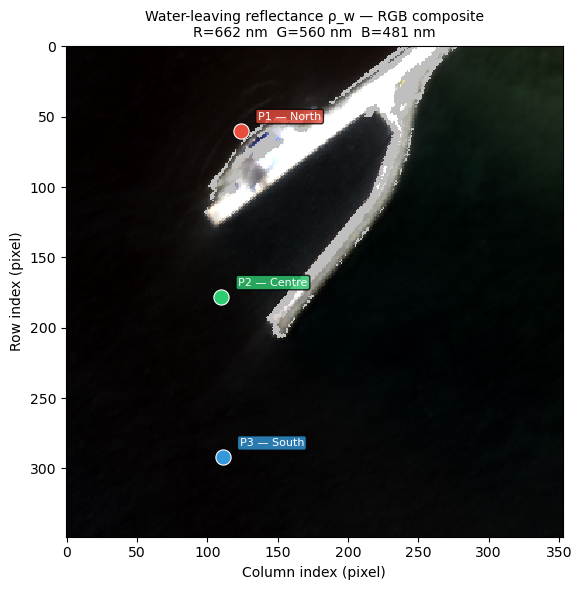

In [17]:
wl = ds.wavelength.values

def nearest_band(target_nm):
    return int(np.abs(wl - target_nm).argmin())

r_i = nearest_band(660)
g_i = nearest_band(560)
b_i = nearest_band(480)

print(f"R channel : {wl[r_i]:.1f} nm (index {r_i})")
print(f"G channel : {wl[g_i]:.1f} nm (index {g_i})")
print(f"B channel : {wl[b_i]:.1f} nm (index {b_i})")

# Build RGB array; NaN → grey
rgb_raw = np.stack([
    rho_w[r_i],
    rho_w[g_i],
    rho_w[b_i],
], axis=-1).astype(np.float32)                      # (ny, nx, 3)

valid_water = np.isfinite(rgb_raw).all(axis=-1)

# Percentile stretch on water pixels only
p2, p98 = np.nanpercentile(rgb_raw[valid_water], [2, 98], axis=0)
rgb_stretched = np.clip((rgb_raw - p2) / (p98 - p2 + 1e-9), 0, 1)

# Grey for non-water / no-data
grey = np.full_like(rgb_stretched, 0.75)
rgb_display = np.where(valid_water[..., np.newaxis], rgb_stretched, grey)

# ── Three water pixel locations for spectrum extraction ────────────────────
pts = [
    {"label": "P1 — North",  "yi": 60,  "xi": 124, "color": "#e74c3c"},
    {"label": "P2 — Centre", "yi": 178, "xi": 110, "color": "#2ecc71"},
    {"label": "P3 — South",  "yi": 292, "xi": 111, "color": "#3498db"},
]

fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(rgb_display, origin="upper", interpolation="none")

for p in pts:
    ax.scatter(p["xi"], p["yi"], s=120, color=p["color"],
               edgecolors="white", linewidths=0.8, zorder=5)
    ax.annotate(p["label"], xy=(p["xi"], p["yi"]),
                xytext=(p["xi"] + 12, p["yi"] - 8),
                color="white", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc=p["color"], alpha=0.8))

ax.set_title("Water-leaving reflectance ρ_w — RGB composite\n"
             f"R={wl[r_i]:.0f} nm  G={wl[g_i]:.0f} nm  B={wl[b_i]:.0f} nm",
             fontsize=10)
ax.set_xlabel("Column index (pixel)")
ax.set_ylabel("Row index (pixel)")
plt.tight_layout()
plt.show()

## 7 — Water-leaving spectra at three locations

We extract ρ_w(λ) at the three marked water pixels and overlay the SMA calibration
slope `a(λ)` on a secondary axis for reference.  The shaded band shows the 95 %
confidence interval of the calibration coefficients.

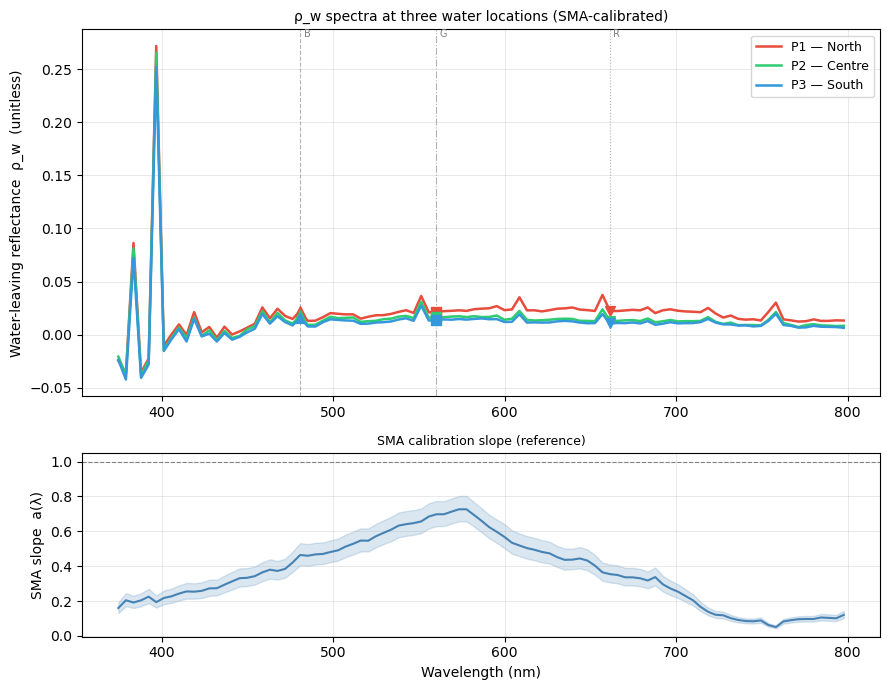

In [ ]:
fig, (ax_spec, ax_cal) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=False,
    gridspec_kw={"height_ratios": [3, 1.5]},
)

# ── Upper panel: ρ_w spectra ───────────────────────────────────────────────
for p in pts:
    spectrum = rho_w[:, p["yi"], p["xi"]]
    ax_spec.plot(wl, spectrum, color=p["color"], lw=1.8, label=p["label"])
    ax_spec.scatter(wl[r_i], spectrum[r_i], color=p["color"], marker="v", s=50, zorder=5)
    ax_spec.scatter(wl[g_i], spectrum[g_i], color=p["color"], marker="s", s=50, zorder=5)
    ax_spec.scatter(wl[b_i], spectrum[b_i], color=p["color"], marker="^", s=50, zorder=5)

# Mark the RGB wavelengths
for wl_target, ch, ls in [(wl[r_i], "R", ":"), (wl[g_i], "G", "-."), (wl[b_i], "B", "--")]:
    ax_spec.axvline(wl_target, color="gray", lw=0.8, ls=ls, alpha=0.6)
    ax_spec.text(wl_target + 2, ax_spec.get_ylim()[1] if ax_spec.get_ylim()[1] > 0 else 0.04,
                 ch, fontsize=7, color="gray", va="top")

ax_spec.set_ylabel("Water-leaving reflectance  ρ_w  (unitless)")
ax_spec.set_title("ρ_w spectra at three water locations (SMA-calibrated)", fontsize=10)
ax_spec.legend(fontsize=9)
# ax_spec.set_ylim(bottom=0)
ax_spec.grid(True, lw=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

## 8 — Tabular summary of the three spectra

A quick look at a few key wavelengths commonly used in optical water-quality
algorithms (blue 443 nm, green 560 nm, red 665 nm, NIR 750 nm).

In [14]:
import pandas as pd

key_bands = {"443 nm": 443, "560 nm": 560, "665 nm": 665, "750 nm": 750}
rows = []
for p in pts:
    row = {"Location": p["label"]}
    for name, target in key_bands.items():
        idx = int(np.abs(wl - target).argmin())
        row[name] = float(rho_w[idx, p["yi"], p["xi"]])
    rows.append(row)

df_summary = pd.DataFrame(rows).set_index("Location")
df_summary.style.format("{:.5f}").set_caption(
    "ρ_w at selected wavelengths (SMA-calibrated)"
)

,443 nm,560 nm,665 nm,750 nm
Location,,,,
P1 — North,0.00288,0.01584,0.00743,0.00087
P2 — Centre,0.00180,0.01239,0.00417,0.00042
P3 — South,0.00129,0.01067,0.00345,0.00036


---

## Summary

| Step | Method / output |
|------|-----------------|
| Load L1C | `Image.from_aabim_nc()` |
| Ancillary | `add_ancillary()` — MERRA-2 GMAO download + cache |
| Calibration | `SMAModel.load()` — plain CSV, no header required |
| Clip bands | `img.mask_wavelength([wl_min, wl_max])` |
| Correction | `img.to_l2r(zarr, cal_model=sma_model, n_workers=4)` |
| Export | `img_l2r.zarr_to_nc(zarr, nc)` — CF-1.0 NetCDF |

The output Zarr store contains: `rho_at_sensor`, `rho_s`, `rho_w`, `rho_w_gl21`,
`ndwi`, `mask_water`, plus all input geometry and ancillary fields.

---
*Generated with [aabim](https://github.com/…)*